In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql import functions as F
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
spark2 = SparkSession.builder \
    .appName("Session_du_pipeline_Ml") \
    .master("yarn") \
    .config("spark.hadoop.fs.defaultFS", "hdfs://namenode:8020") \
    .config("spark.hadoop.yarn.resourcemanager.hostname", "resourcemanager") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/22 00:05:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/22 00:05:49 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


In [6]:
spark2.version

'3.5.7'

## Une petite parenthese

In [7]:
df = spark2.read.option("mergeSchema", "true").parquet("hdfs://namenode:8020/ben/dataLake/")

In [8]:
df.show(truncate=False)

+-------------------------------------------------------------+----+----------------------------------------+-----------------------------------------------------------------+----------------+-------------------+------------------------------------------------------------------------+------------------------------------------------------+----------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|poste                                                        |lien|entreprise                              |region                                 

In [9]:
df_etude1 = df.groupby("niveau_experience")\
       .count()\
       .orderBy(desc("count"))\
       .limit(30)\
       .withColumnRenamed("count", "nbre_experience")\
       .toPandas()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


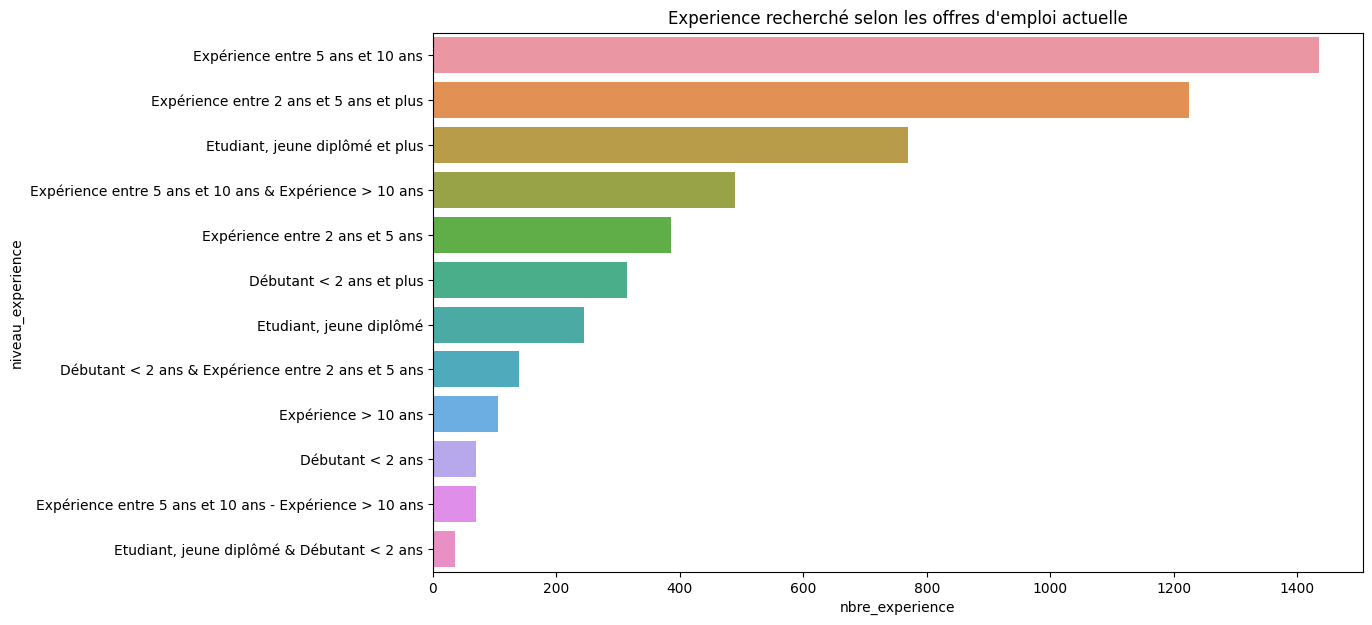

In [10]:
plt.figure(figsize=(12,7))
sns.barplot(data=df_etude1, y="niveau_experience", x="nbre_experience")
plt.title("Experience recherché selon les offres d'emploi actuelle")
plt.show()

## Revue de notre dataset 

In [11]:
### ---------------------- nos liens --------------------------------------------####
url = "jdbc:postgresql://postgres_warehouse:5432/Warehouse_DB"
user = "admin"
password = "admin_pwd"
driver = "org.postgresql.Driver"

In [12]:
df_lecture = spark2.read \
    .format("jdbc") \
    .option("url", url) \
    .option("dbtable", "dataset_ml") \
    .option("user", user) \
    .option("password", password) \
    .option("driver", driver) \
    .load()

In [13]:
df_lecture.count()

7056

In [14]:
df_lecture.show(10, truncate=False)

+----------------+-----------------------------------+----+--------------+-------------------------------------+-----------------------+-------+---------------------+-------------+------------------+
|entreprise      |poste                              |lien|competence    |formation                            |niveau_etude           |contrat|experience           |region       |date_de_pulication|
+----------------+-----------------------------------+----+--------------+-------------------------------------+-----------------------+-------+---------------------+-------------+------------------+
|INTRA INTERIM SN|Ouvrier d’Usine - Roumanie (Europe)|NULL|Accompagnement|Niveau d’anglais intermédiaire requis|Qualification avant bac|CDI    |Etudiant             |International|20.06.2025        |
|INTRA INTERIM SN|Ouvrier d’Usine - Roumanie (Europe)|NULL|Accompagnement|Niveau d’anglais intermédiaire requis|Qualification avant bac|CDI    |jeune diplômé et plus|International|20.06.2025        |


In [15]:
df_lecture.show(5, truncate=100)

+----------------+-----------------------------------+----+--------------+-------------------------------------+-----------------------+-------+---------------------+-------------+------------------+
|      entreprise|                              poste|lien|    competence|                            formation|           niveau_etude|contrat|           experience|       region|date_de_pulication|
+----------------+-----------------------------------+----+--------------+-------------------------------------+-----------------------+-------+---------------------+-------------+------------------+
|INTRA INTERIM SN|Ouvrier d’Usine - Roumanie (Europe)|NULL|Accompagnement|Niveau d’anglais intermédiaire requis|Qualification avant bac|    CDI|             Etudiant|International|        20.06.2025|
|INTRA INTERIM SN|Ouvrier d’Usine - Roumanie (Europe)|NULL|Accompagnement|Niveau d’anglais intermédiaire requis|Qualification avant bac|    CDI|jeune diplômé et plus|International|        20.06.2025|


In [16]:
df_lecture.select('entreprise').distinct().show(truncate=False)

+-------------------------------------------+
|entreprise                                 |
+-------------------------------------------+
|Concentrix                                 |
|UNFPA                                      |
|Serviq SARL                                |
|TECTRA SÉNÉGAL                             |
|Société Internationale d'Ingénierie Conseil|
|Olam Agri                                  |
|Ove residence                              |
|MOUABI                                     |
|Verti Africa                               |
|Agenceweb.fr                               |
|E.B.S                                      |
|DESK SUARL                                 |
|Eloh Center                                |
|VISION PLUS VOYAGE                         |
|Profil SN                                  |
|Open Society Foundations                   |
|Top Management 24                          |
|SOCIÉTÉ DE PROMOTION ET DE CONSTRUCTION    |
|NEXGEN TALENT                    

In [17]:
df_lecture.select('niveau_etude').distinct().show(truncate=False)

+-----------------------+
|niveau_etude           |
+-----------------------+
|Bac                    |
|Bac+2                  |
|plus                   |
|Qualification avant bac|
|Bac+3                  |
|Bac+1                  |
|Bac+2 - Bac+3          |
|Bac+4 - Bac+5          |
|Bac+5                  |
|Bac+4                  |
|NULL                   |
+-----------------------+



In [18]:
df_lecture.select('experience').distinct().show(truncate=False)

+---------------------------------------+
|experience                             |
+---------------------------------------+
|Débutant < 2 ans                       |
|Expérience entre 2 ans et 5 ans        |
|Expérience entre 2 ans et 5 ans et plus|
|Etudiant                               |
|jeune diplômé                          |
|Expérience > 10 ans                    |
|Débutant < 2 ans et plus               |
|Expérience entre 5 ans et 10 ans       |
|jeune diplômé et plus                  |
|NULL                                   |
+---------------------------------------+



In [19]:
df_lecture.select('poste').distinct().show(truncate=False)

+-----------------------------------------------------------------------------------+
|poste                                                                              |
+-----------------------------------------------------------------------------------+
|QHSE Manager                                                                       |
|Agent de Confection et d´Assemblage - Dakar / Almadies                             |
|Health Systems Strengthening Experts                                               |
|Technicien en archéologie                                                          |
|Consultant Junior Advisory                                                         |
|Responsable des Relations Publiques Extérieures – Présidence COJOJ                 |
|Conseillers Client Télévente                                                       |
|Health Economics and Financing Experts                                             |
|Stagiaire Chargé(e) de la Relation Client            

In [20]:
df_lecture.select('lien').distinct().show(truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------+
|lien                                                                                                                                              |
+--------------------------------------------------------------------------------------------------------------------------------------------------+
|https://www.emploidakar.com/offre-demploi/modec-dakar-senegal-cdi-offshore-metering-technician/                                                   |
|https://www.emploidakar.com/offre-demploi/pacta-dakar-cdd-cdi-juriste-en-droit-des-societes-gouvernance/                                          |
|https://www.emploidakar.com/offre-demploi/universite-amadou-mahtar-mbow-uam-diamniadio-senegal-cdd-cdi-02-enseignants-chercheurs-en-mathematiques/|
|https://www.emploidakar.com/offre-demploi/bia-group-dakar-senegal-cdd-country-sales-manager/             

In [21]:

df_lecture.select('date_de_pulication') \
          .distinct() \
          .orderBy(col('date_de_pulication').asc()) \
          .show(truncate=False)

+------------------+
|date_de_pulication|
+------------------+
|NULL              |
|01.07.2025        |
|01.08.2025        |
|02.07.2025        |
|02.08.2025        |
|04.06.2025        |
|04.07.2025        |
|04.08.2025        |
|05.08.2025        |
|06.08.2025        |
|07.07.2025        |
|07.08.2025        |
|08.08.2025        |
|09.07.2025        |
|10.06.2025        |
|10.07.2025        |
|11.06.2025        |
|11.07.2025        |
|12.06.2025        |
|13.06.2025        |
+------------------+
only showing top 20 rows



In [22]:
df_lecture.select('competence').distinct().show(truncate=False)

+-----------------------+
|competence             |
+-----------------------+
|LARAVEL                |
|C#                     |
|Prospection            |
|Modélisation Financière|
|Électronique           |
|DNS                    |
|Productivité           |
|API                    |
|Produit Fini           |
|Stratégie              |
|DJANGO                 |
|Stratégie Marketing    |
|Assistanat             |
|SHELL                  |
|WORDPRESS              |
|DYNATRACE              |
|Plomberie              |
|Community Management   |
|ARM                    |
|PUPPET                 |
+-----------------------+
only showing top 20 rows



In [23]:
df_lecture.groupby("entreprise").count().show()

+--------------------+-----+
|          entreprise|count|
+--------------------+-----+
|          Concentrix|    3|
|               UNFPA|    1|
|         Serviq SARL|    1|
|      TECTRA SÉNÉGAL|  280|
|Société Internati...|    1|
|           Olam Agri|    1|
|       Ove residence|    1|
|              MOUABI|    2|
|        Verti Africa|    1|
|        Agenceweb.fr|    1|
|               E.B.S|    1|
|          DESK SUARL|    2|
|         Eloh Center|    1|
|  VISION PLUS VOYAGE|    1|
|           Profil SN|    1|
|Open Society Foun...|    1|
|   Top Management 24|    2|
|SOCIÉTÉ DE PROMOT...|   17|
|       NEXGEN TALENT|   33|
|     Notre assurance|    1|
+--------------------+-----+
only showing top 20 rows



In [24]:
df_lecture.select('poste','competence','formation').distinct().show(truncate=False)

+------------------------------------------------------------+-----------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|poste                                                       |competence       |formation                                                                                                                                                                                                  |
+------------------------------------------------------------+-----------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|OBJECTIVE-C Developer (M/F)                                 |HTML             |Bachelors degree in Software Engineering or related.             

# Debut de l' EDA 

## EDA données brutes

In [25]:
donnees_brutes = spark2.read \
    .format("jdbc") \
    .option("url", url) \
    .option("dbtable", "offres_emploi") \
    .option("user", user) \
    .option("password", password) \
    .option("driver", driver) \
    .load()

In [26]:
donnees_brutes.show(2)

+----------------+--------------------+--------------------+--------------------+--------------------+------------------+--------------------+----+--------------------+-------------------+
|      entreprise|               poste|          competence|           formation|        niveau_etude|           contrat|          experience|lien|              region|date_de_publication|
+----------------+--------------------+--------------------+--------------------+--------------------+------------------+--------------------+----+--------------------+-------------------+
|INTRA INTERIM SN|Ouvrier d’Usine -...|[Accompagnement, ...|Niveau d’anglais ...|[Qualification av...|    [CDI, Intérim]|[Etudiant, jeune ...|NULL|       International|         20.06.2025|
|        TALIACOM|   Graphiste - Dakar|               [CMS]|Vous acquérez vot...|[Bac+2, Bac+3, Ba...|[Stage, Freelance]|[Expérience entre...|NULL|Dakar - Thiès & I...|         01.08.2025|
+----------------+--------------------+----------------

In [27]:
donnees_brutes.groupBy("entreprise") \
          .count() \
          .orderBy(desc("count")) \
          .show()

+--------------------+-----+
|          entreprise|count|
+--------------------+-----+
|         AFRICASHORE|  126|
|      TECTRA SÉNÉGAL|   48|
|            Elite RH|   30|
|Phoenix Consultin...|   27|
|Université Amadou...|   24|
|              WEBTEL|   21|
|                UCAD|   21|
|    INTRA INTERIM SN|   18|
|          ONE TO ONE|   15|
|        TIENS DS COM|   15|
|                 MSH|   15|
|        KPMG Sénégal|   15|
|  Sama Mbey (myAgro)|   12|
|IQRA Bilingual Ac...|   12|
|         Sen Intérim|   12|
|    Upright Partners|   12|
|               Modec|   12|
|      CABINET CARREE|    9|
|SOCIÉTÉ DE PROMOT...|    9|
|          Concentrix|    9|
+--------------------+-----+
only showing top 20 rows



In [28]:
donnees_brutes.groupBy("poste") \
          .count() \
          .orderBy(desc("count")) \
          .show(truncate=False)

+------------------------------------------------------------------+-----+
|poste                                                             |count|
+------------------------------------------------------------------+-----+
|Commerciaux                                                       |12   |
|Consultant                                                        |9    |
|Assistant RH                                                      |6    |
|Commercial Terrain - Saint-Louis                                  |6    |
|Business Developer                                                |6    |
|Manager Data Engineer                                             |6    |
|Commercial Terrain                                                |6    |
|Téléconseillers                                                   |6    |
|Télévendeur Expérimenté - Dakar                                   |6    |
|Commercial(e)                                                     |6    |
|Commercial              

In [29]:
donnees_brutes.groupBy("competence") \
          .count() \
          .orderBy(desc("count")) \
          .show(truncate=False)

+----------------------------------------------------------------------------------------------------------------------------+-----+
|competence                                                                                                                  |count|
+----------------------------------------------------------------------------------------------------------------------------+-----+
|NULL                                                                                                                        |792  |
|[Vente]                                                                                                                     |21   |
|[ABAP, SAP]                                                                                                                 |6    |
|[Comptabilité, Finance, Gestion]                                                                                            |6    |
|[SAP]                                                               

## EDA données Ml 

In [30]:
df_lecture.show(5)

+----------------+--------------------+----+--------------+--------------------+--------------------+-------+--------------------+-------------+------------------+
|      entreprise|               poste|lien|    competence|           formation|        niveau_etude|contrat|          experience|       region|date_de_pulication|
+----------------+--------------------+----+--------------+--------------------+--------------------+-------+--------------------+-------------+------------------+
|INTRA INTERIM SN|Ouvrier d’Usine -...|NULL|Accompagnement|Niveau d’anglais ...|Qualification ava...|    CDI|            Etudiant|International|        20.06.2025|
|INTRA INTERIM SN|Ouvrier d’Usine -...|NULL|Accompagnement|Niveau d’anglais ...|Qualification ava...|    CDI|jeune diplômé et ...|International|        20.06.2025|
|INTRA INTERIM SN|Ouvrier d’Usine -...|NULL|Accompagnement|Niveau d’anglais ...|Qualification ava...|Intérim|            Etudiant|International|        20.06.2025|
|INTRA INTERIM S

In [31]:
df_lecture.printSchema()

root
 |-- entreprise: string (nullable = true)
 |-- poste: string (nullable = true)
 |-- lien: string (nullable = true)
 |-- competence: string (nullable = true)
 |-- formation: string (nullable = true)
 |-- niveau_etude: string (nullable = true)
 |-- contrat: string (nullable = true)
 |-- experience: string (nullable = true)
 |-- region: string (nullable = true)
 |-- date_de_pulication: string (nullable = true)



In [32]:
df_lecture.select(df_lecture.entreprise).distinct().show()

+--------------------+
|          entreprise|
+--------------------+
|          Concentrix|
|               UNFPA|
|         Serviq SARL|
|      TECTRA SÉNÉGAL|
|Société Internati...|
|           Olam Agri|
|       Ove residence|
|              MOUABI|
|        Verti Africa|
|        Agenceweb.fr|
|               E.B.S|
|          DESK SUARL|
|         Eloh Center|
|  VISION PLUS VOYAGE|
|           Profil SN|
|Open Society Foun...|
|   Top Management 24|
|SOCIÉTÉ DE PROMOT...|
|       NEXGEN TALENT|
|     Notre assurance|
+--------------------+
only showing top 20 rows



In [33]:
df_lecture.groupBy("entreprise") \
          .count() \
          .orderBy(desc("count")) \
          .show()


+--------------------+-----+
|          entreprise|count|
+--------------------+-----+
|              WEBTEL| 1133|
|         AFRICASHORE|  909|
|     MYRIADE CAPITAL|  560|
|        TIENS DS COM|  482|
|                NULL|  340|
|    INTRA INTERIM SN|  304|
|      TECTRA SÉNÉGAL|  280|
|          ONE TO ONE|  242|
|          SENEA FOOD|  240|
|        NOMADAW SARL|  192|
|           Timanarii|  168|
| SMART GROUP SÉNÉGAL|  168|
|SALVI LIGHTING SE...|  152|
|ACDH SERVICE CANADA |  128|
|          OPTISTAFF |  128|
|      GLOBAL CONSULT|   96|
|RESIDENCE HOTELIE...|   96|
|          AFRICAWORK|   90|
|             WANEKOO|   88|
|    GROUPE TOP INTER|   80|
+--------------------+-----+
only showing top 20 rows



In [34]:
df_lecture.groupBy("poste") \
          .count() \
          .distinct()\
          .orderBy(desc("count")) \
          .withColumnRenamed('count', 'nombre_d_offre')\
          .show(10, truncate=False)


+------------------------------------------------------+--------------+
|poste                                                 |nombre_d_offre|
+------------------------------------------------------+--------------+
|Chargé(s) d´Affaires  - Dakar                         |560           |
|Comptable - Dakar                                     |340           |
|Business Developer (H/F) - Dakar                      |288           |
|Commercial BtoB - Dakar                               |252           |
|Planificateur(trice) Production - Ouakam              |240           |
|Commercial / Business Developper - Dakar              |224           |
|Ouvrier d’Usine - Roumanie (Europe)                   |224           |
|Business Development Representative (BDR) - Dakar     |224           |
|Chargé(e) de Communication Digitale - Dakar           |176           |
|Agent de Confection et d´Assemblage - Dakar / Almadies|168           |
+------------------------------------------------------+--------

In [35]:
df_lecture.groupBy("competence") \
          .count() \
          .orderBy(desc("count")) \
          .show()

+--------------------+-----+
|          competence|count|
+--------------------+-----+
|               Vente|  448|
|                NULL|  346|
|       Communication|  279|
|           Marketing|  273|
|         Négociation|  235|
|                 CRM|  182|
|             Gestion|  176|
|       Télémarketing|  165|
|         Prospection|  145|
|         Maintenance|  124|
|             Qualité|  124|
|        Comptabilité|  104|
|             Finance|   96|
|          Production|   96|
|          Management|   76|
|           Formation|   75|
| Techniques de Vente|   74|
|Développement Com...|   68|
|                 CVS|   66|
|Gestion de Portef...|   64|
+--------------------+-----+
only showing top 20 rows



In [36]:
df_lecture.groupBy("formation") \
          .count() \
          .orderBy(desc("count")) \
          .show(5,truncate=False )

+---------------------------------------------------------------------------------------------+-----+
|formation                                                                                    |count|
+---------------------------------------------------------------------------------------------+-----+
|Bachelors degree in Software Engineering or related.                                         |578  |
|Niveau Bac+3 en banque finance assurances                                                    |560  |
|Expérience professionnelle en comptabilité (stages, expérience professionnelle en entreprise)|340  |
|Français parfaitement maîtrisé à l’oral comme à l’écrit, avec accent neutre                  |288  |
|NULL                                                                                         |255  |
+---------------------------------------------------------------------------------------------+-----+
only showing top 5 rows



In [37]:
df_lecture.select(df_lecture.lien).distinct().show(3, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------+
|lien                                                                                                                                              |
+--------------------------------------------------------------------------------------------------------------------------------------------------+
|https://www.emploidakar.com/offre-demploi/modec-dakar-senegal-cdi-offshore-metering-technician/                                                   |
|https://www.emploidakar.com/offre-demploi/pacta-dakar-cdd-cdi-juriste-en-droit-des-societes-gouvernance/                                          |
|https://www.emploidakar.com/offre-demploi/universite-amadou-mahtar-mbow-uam-diamniadio-senegal-cdd-cdi-02-enseignants-chercheurs-en-mathematiques/|
+---------------------------------------------------------------------------------------------------------

In [38]:
df_lecture.filter(df_lecture.lien.isNull()).count()

6803

In [39]:
df_traite = df_lecture.withColumn(
    "lien", 
    when(df_lecture.lien.isNull(), "https://www.emploisenegal.com/recherche-jobs-senegal").otherwise(df_lecture.lien))

# Ici nous savons d'avance que les lignes qui n'ont pas de liens viennent de quel sites, voila le pourquoi de ce remplacement.

In [40]:
df_traite.filter(df_traite.lien.isNull()).count()

0

In [41]:
df_lecture.filter(df_lecture.lien.isNull())

DataFrame[entreprise: string, poste: string, lien: string, competence: string, formation: string, niveau_etude: string, contrat: string, experience: string, region: string, date_de_pulication: string]

In [42]:
df_lecture.filter(df_lecture.lien.isNotNull()).count()

253

# Analyse Univarié 

## Compter les colonnes nules dans notre dataset / les differents valeurs EDA

In [43]:
df_traite.filter(df_traite.lien.isNull()).count()

0

In [44]:
df_traite.filter(df_traite.competence.isNull()).count()

346

### colonne entreprise

In [45]:
df_traite.groupby("entreprise")\
       .count()\
       .distinct()\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_entreprise").show(10)

+----------------+---------------+
|      entreprise|nbre_entreprise|
+----------------+---------------+
|          WEBTEL|           1133|
|     AFRICASHORE|            909|
| MYRIADE CAPITAL|            560|
|    TIENS DS COM|            482|
|            NULL|            340|
|INTRA INTERIM SN|            304|
|  TECTRA SÉNÉGAL|            280|
|      ONE TO ONE|            242|
|      SENEA FOOD|            240|
|    NOMADAW SARL|            192|
+----------------+---------------+
only showing top 10 rows



In [46]:
df_entrepris = df_traite.groupby("entreprise")\
       .count()\
       .limit(30)\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_entreprise").toPandas()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


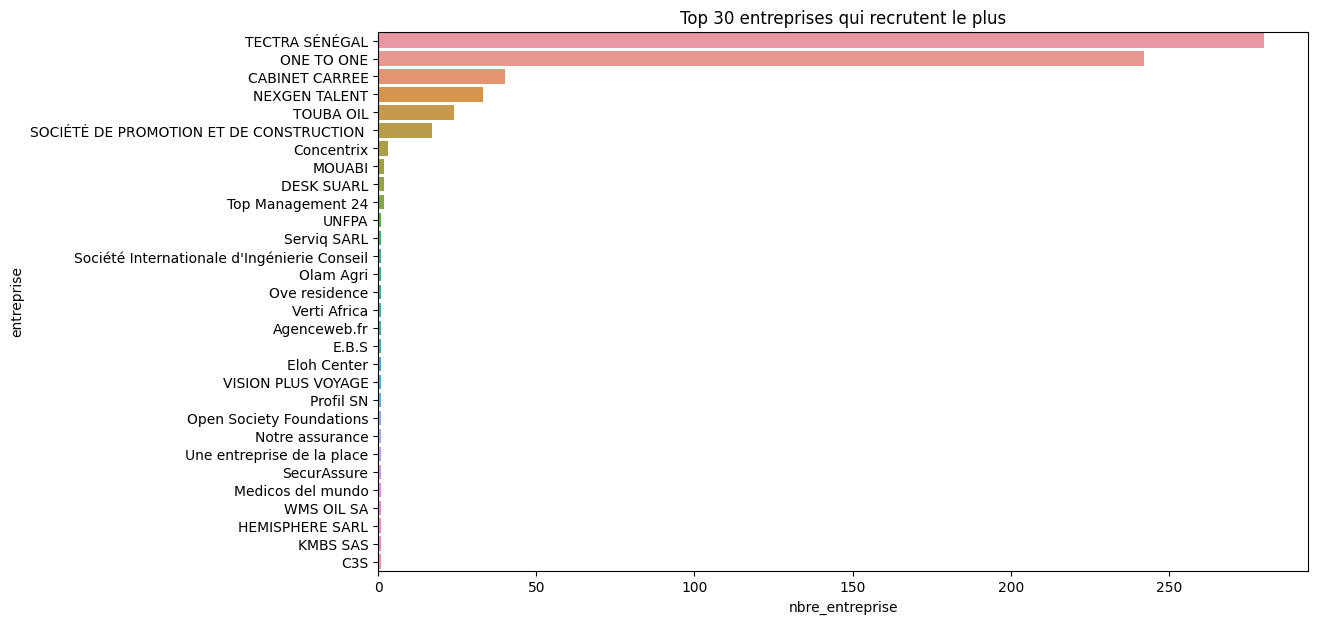

In [47]:

plt.figure(figsize=(12,7))
sns.barplot(data=df_entrepris, y="entreprise", x="nbre_entreprise")
plt.title("Top 30 entreprises qui recrutent le plus")
plt.show()



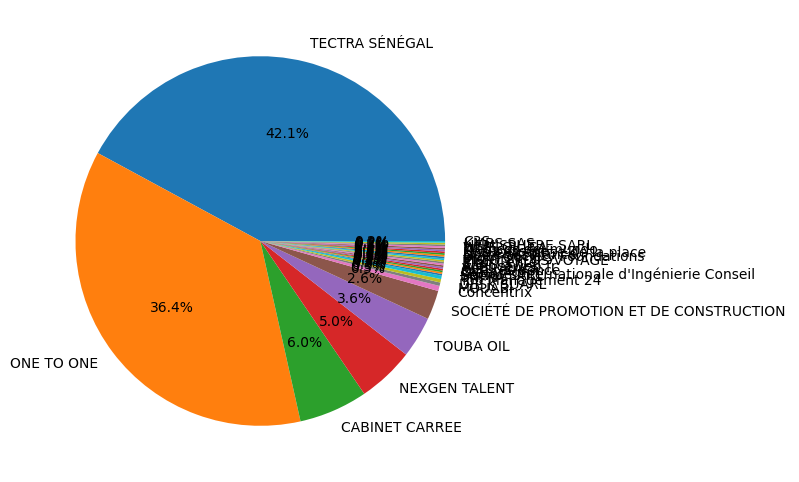

In [48]:
plt.figure(figsize=(6,6))
plt.pie(df_entrepris["nbre_entreprise"], labels=df_entrepris["entreprise"], autopct="%1.1f%%")
plt.show()

### Colonne Competence

In [49]:
df_traite.groupby("competence")\
       .count()\
       .distinct()\
       .orderBy(desc("count"))\
    .withColumnRenamed('count', 'nombre_de_compet')\
    .show(10)
        #.withColumnRenamed("count","nombre_compe")\ 
      # .show()

+-------------+----------------+
|   competence|nombre_de_compet|
+-------------+----------------+
|        Vente|             448|
|         NULL|             346|
|Communication|             279|
|    Marketing|             273|
|  Négociation|             235|
|          CRM|             182|
|      Gestion|             176|
|Télémarketing|             165|
|  Prospection|             145|
|      Qualité|             124|
+-------------+----------------+
only showing top 10 rows



In [50]:
df_traite_comp = df_traite.groupby("competence")\
       .count()\
       .distinct()\
       .orderBy(desc("count"))\
    .withColumnRenamed('count', 'nombre_de_compet')\
     .toPandas()

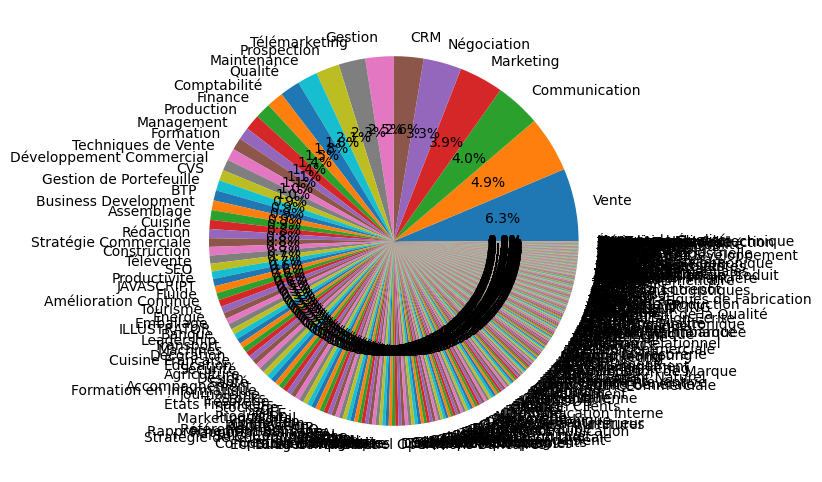

In [51]:
plt.figure(figsize=(6,6))
plt.pie(df_traite_comp["nombre_de_compet"], labels=df_traite_comp["competence"], autopct="%1.1f%%")
plt.show()

In [52]:
df_competence = df_traite.groupby("competence")\
       .count()\
       .limit(30) \
       .orderBy(desc("count"))\
    .withColumnRenamed('count', 'nombre_de_compet')\
     .toPandas()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


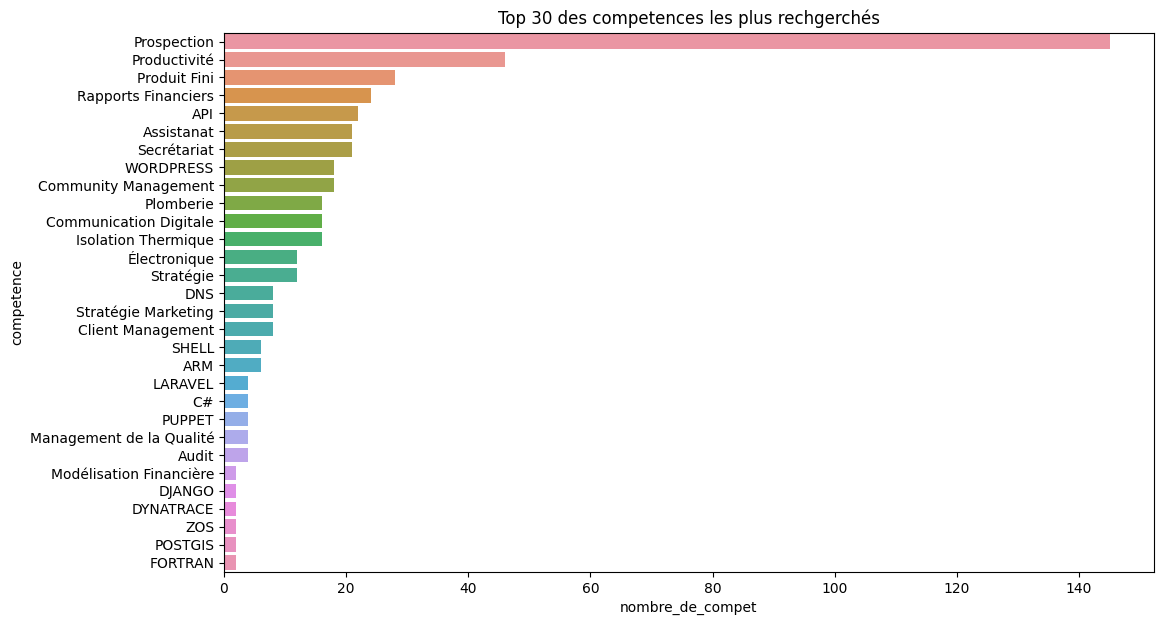

In [53]:
plt.figure(figsize=(12,7))
sns.barplot(data=df_competence, y="competence", x="nombre_de_compet")
plt.title("Top 30 des competences les plus rechgerchés")
plt.show()

### Colonne Poste 

In [54]:
df_traite.groupby("poste")\
       .count()\
       .distinct()\
       .orderBy(desc("count"))\
    .withColumnRenamed('count', 'nombre_poste')\
    .show(10)

+--------------------+------------+
|               poste|nombre_poste|
+--------------------+------------+
|Chargé(s) d´Affai...|         560|
|   Comptable - Dakar|         340|
|Business Develope...|         288|
|Commercial BtoB -...|         252|
|Planificateur(tri...|         240|
|Commercial / Busi...|         224|
|Ouvrier d’Usine -...|         224|
|Business Developm...|         224|
|Chargé(e) de Comm...|         176|
|Agent de Confecti...|         168|
+--------------------+------------+
only showing top 10 rows



In [55]:
data_poste = df_traite.groupby("poste")\
       .count()\
       .orderBy(desc("count"))\
    .withColumnRenamed('count', 'nombre_poste')\
    .toPandas()

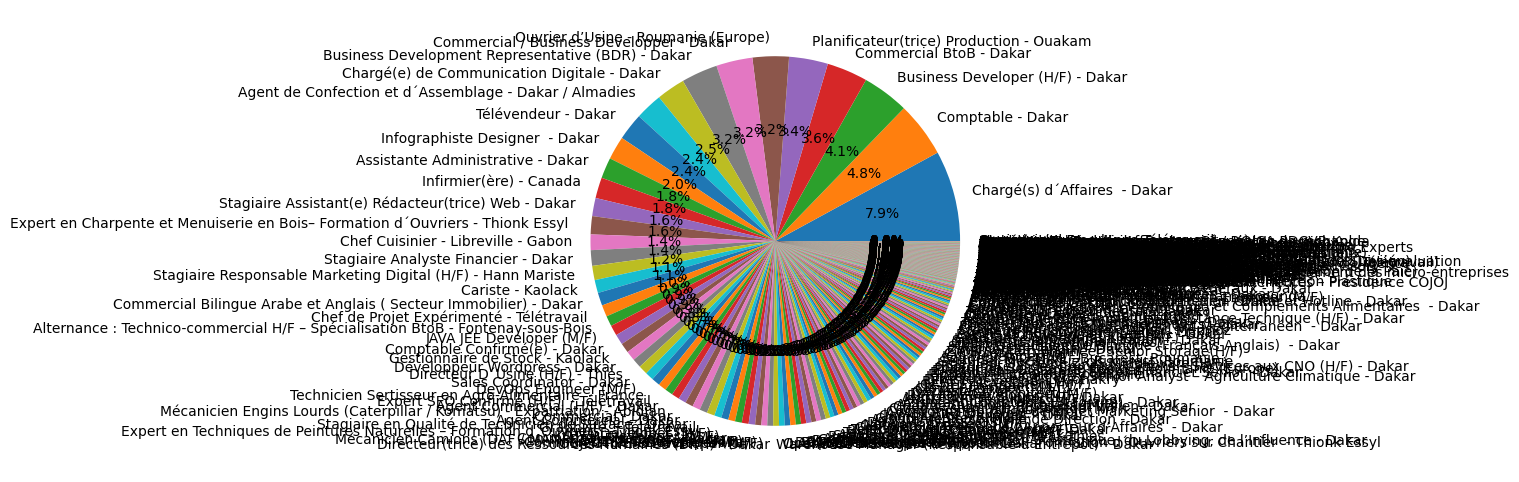

In [56]:
plt.figure(figsize=(6,6))
plt.pie(data_poste["nombre_poste"], labels=data_poste["poste"], autopct="%1.1f%%")
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


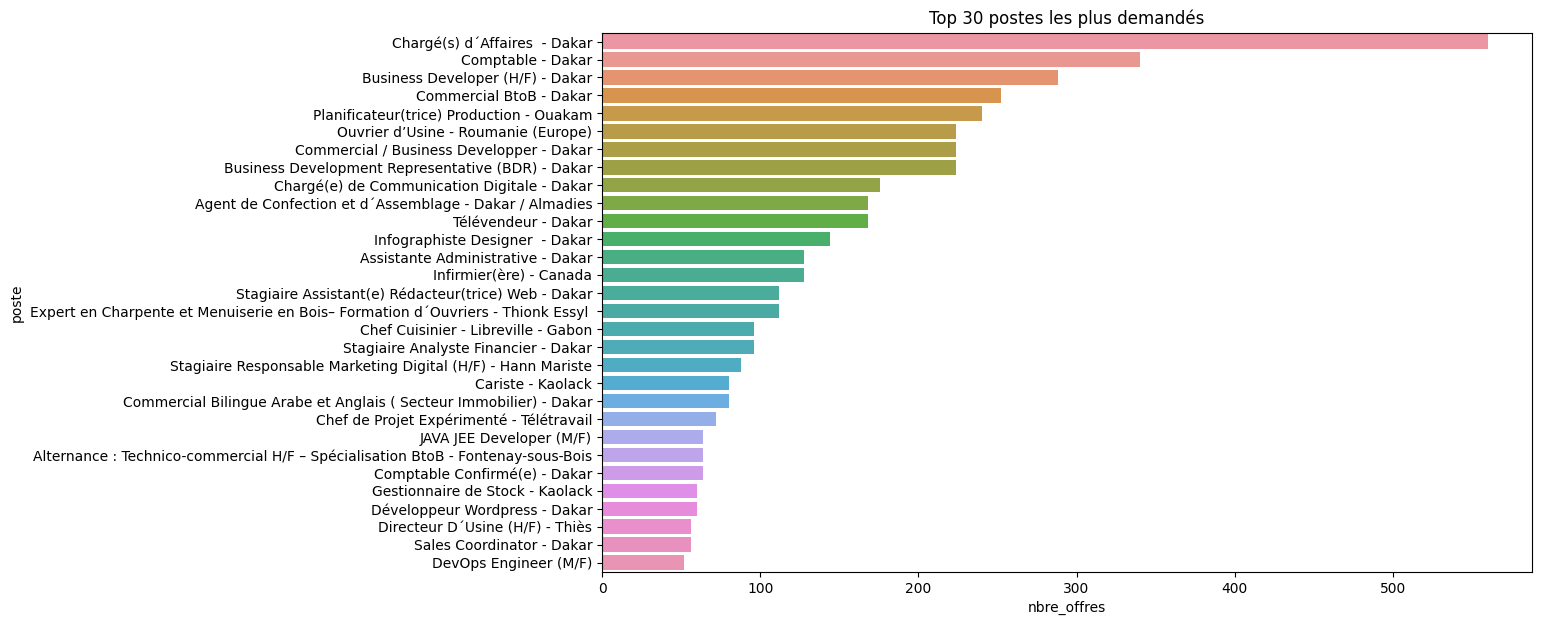

In [57]:
df_poste = (
    df_traite.groupBy("poste")
      .count()
      .orderBy(desc("count"))
      .limit(30)
      .withColumnRenamed("count", "nbre_offres")
      .toPandas()
)

plt.figure(figsize=(12,7))
sns.barplot(data=df_poste, y="poste", x="nbre_offres")
plt.title("Top 30 postes les plus demandés")
plt.show()


### Niveau etude 

In [58]:
df_traite.groupby("niveau_etude")\
       .count()\
       .distinct()\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_niveau_etude")\
    .show(15, truncate=False)

+-----------------------+-----------------+
|niveau_etude           |nbre_niveau_etude|
+-----------------------+-----------------+
|Bac+3                  |1924             |
|plus                   |1021             |
|Bac+5                  |1018             |
|Bac+4                  |931              |
|Bac+2                  |694              |
|Bac                    |473              |
|Bac+1                  |470              |
|NULL                   |253              |
|Qualification avant bac|239              |
|Bac+2 - Bac+3          |30               |
|Bac+4 - Bac+5          |3                |
+-----------------------+-----------------+



In [59]:
df_traite = df_traite.withColumn(
    "niveau_etude",
    split(df_traite.niveau_etude, r"\s*(-)\s*")
)

In [60]:
df_traite.groupby("niveau_etude")\
       .count()\
       .distinct()\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_niveau_etude")\
    .show(10, truncate=False)


+-------------------------+-----------------+
|niveau_etude             |nbre_niveau_etude|
+-------------------------+-----------------+
|[Bac+3]                  |1924             |
|[plus]                   |1021             |
|[Bac+5]                  |1018             |
|[Bac+4]                  |931              |
|[Bac+2]                  |694              |
|[Bac]                    |473              |
|[Bac+1]                  |470              |
|NULL                     |253              |
|[Qualification avant bac]|239              |
|[Bac+2, Bac+3]           |30               |
+-------------------------+-----------------+
only showing top 10 rows



In [61]:
df_traite.printSchema()

root
 |-- entreprise: string (nullable = true)
 |-- poste: string (nullable = true)
 |-- lien: string (nullable = true)
 |-- competence: string (nullable = true)
 |-- formation: string (nullable = true)
 |-- niveau_etude: array (nullable = true)
 |    |-- element: string (containsNull = false)
 |-- contrat: string (nullable = true)
 |-- experience: string (nullable = true)
 |-- region: string (nullable = true)
 |-- date_de_pulication: string (nullable = true)



In [62]:
df_traite = df_traite.select(
    df_traite.entreprise, df_traite.poste, df_traite.lien,\
    df_traite.competence, df_traite.formation,\
    explode_outer(col("niveau_etude")).alias("niveau_etude"), df_traite.contrat, df_traite.experience,\
    df_traite.region, df_traite.date_de_pulication)

df_traite.show(5, truncate=False)

+----------------+-----------------------------------+----------------------------------------------------+--------------+-------------------------------------+-----------------------+-------+---------------------+-------------+------------------+
|entreprise      |poste                              |lien                                                |competence    |formation                            |niveau_etude           |contrat|experience           |region       |date_de_pulication|
+----------------+-----------------------------------+----------------------------------------------------+--------------+-------------------------------------+-----------------------+-------+---------------------+-------------+------------------+
|INTRA INTERIM SN|Ouvrier d’Usine - Roumanie (Europe)|https://www.emploisenegal.com/recherche-jobs-senegal|Accompagnement|Niveau d’anglais intermédiaire requis|Qualification avant bac|CDI    |Etudiant             |International|20.06.2025        |
|INTRA I

In [63]:
df_traite = df_traite.withColumn(
    "niveau_etude",
    when(col("niveau_etude").isNull(), None)
    .otherwise(col("niveau_etude"))
)

In [64]:
df_traite.groupby("niveau_etude")\
       .count()\
       .distinct()\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_niveau_etude")\
    .show(15, truncate=False)

+-----------------------+-----------------+
|niveau_etude           |nbre_niveau_etude|
+-----------------------+-----------------+
|Bac+3                  |1954             |
|plus                   |1021             |
|Bac+5                  |1021             |
|Bac+4                  |934              |
|Bac+2                  |724              |
|Bac                    |473              |
|Bac+1                  |470              |
|NULL                   |253              |
|Qualification avant bac|239              |
+-----------------------+-----------------+



In [65]:
df_traite.printSchema()

root
 |-- entreprise: string (nullable = true)
 |-- poste: string (nullable = true)
 |-- lien: string (nullable = true)
 |-- competence: string (nullable = true)
 |-- formation: string (nullable = true)
 |-- niveau_etude: string (nullable = true)
 |-- contrat: string (nullable = true)
 |-- experience: string (nullable = true)
 |-- region: string (nullable = true)
 |-- date_de_pulication: string (nullable = true)



In [66]:
data_niveau_etude = df_traite.groupby("niveau_etude")\
       .count()\
       .distinct()\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_niveau_etude")\
       .toPandas()

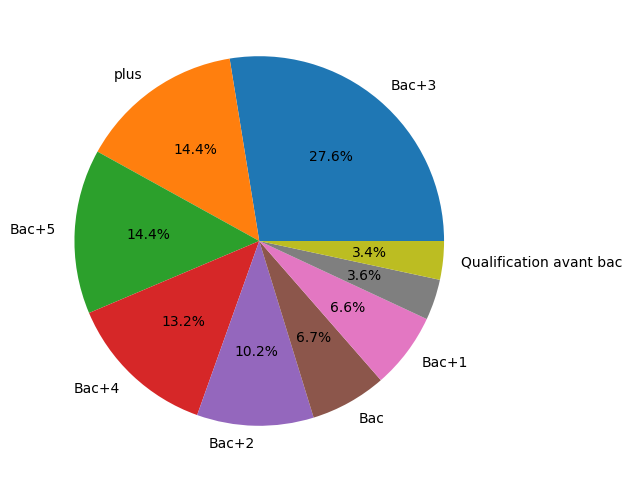

In [67]:
plt.figure(figsize=(6,6))
plt.pie(data_niveau_etude["nbre_niveau_etude"], labels=data_niveau_etude["niveau_etude"], autopct="%1.1f%%")
plt.show()

In [68]:
df_etude = df_traite.groupby("niveau_etude")\
       .count()\
       .limit(30)\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_niveau_etude")\
       .toPandas()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


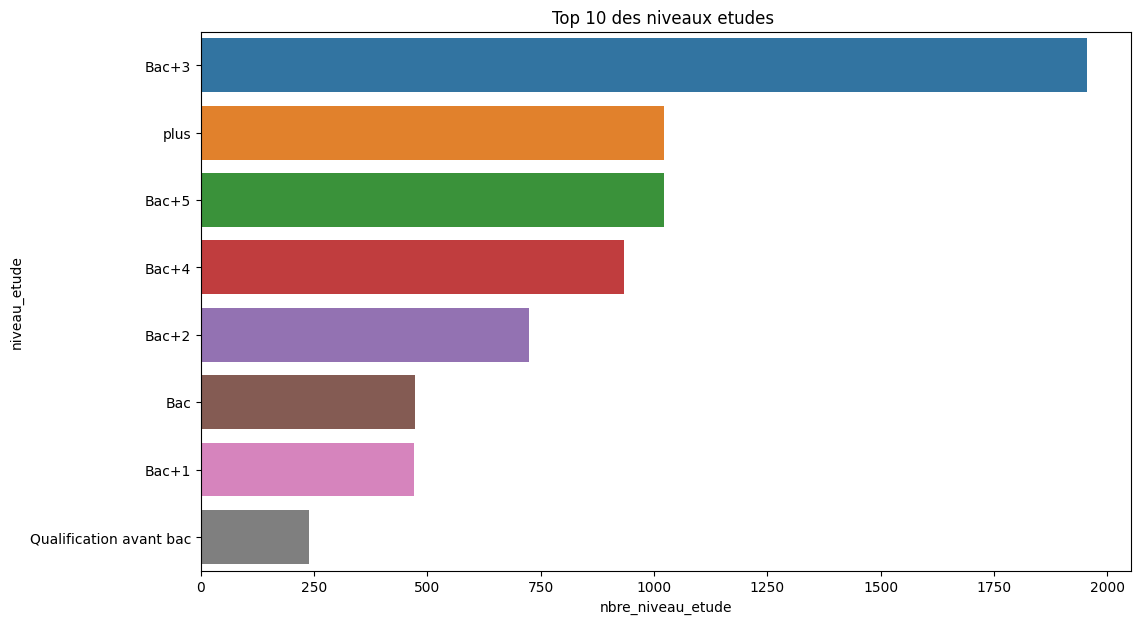

In [69]:
plt.figure(figsize=(12,7))
sns.barplot(data=df_etude, y="niveau_etude", x="nbre_niveau_etude")
plt.title("Top 10 des niveaux etudes ")
plt.show()

### formation 

In [70]:
df_traite.groupby("formation")\
       .count()\
       .distinct()\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_formation")\
    .show(10, truncate=False)

+------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------+
|formation                                                                                                                                                   |nbre_formation|
+------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------+
|Bachelors degree in Software Engineering or related.                                                                                                        |578           |
|Niveau Bac+3 en banque finance assurances                                                                                                                   |560           |
|Expérience professionnelle en comptabilité (stages, expérience professionnelle en entreprise)                                    

In [71]:
data_formation = df_traite.groupby("formation")\
       .count()\
       .distinct()\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_formation")\
        .toPandas()

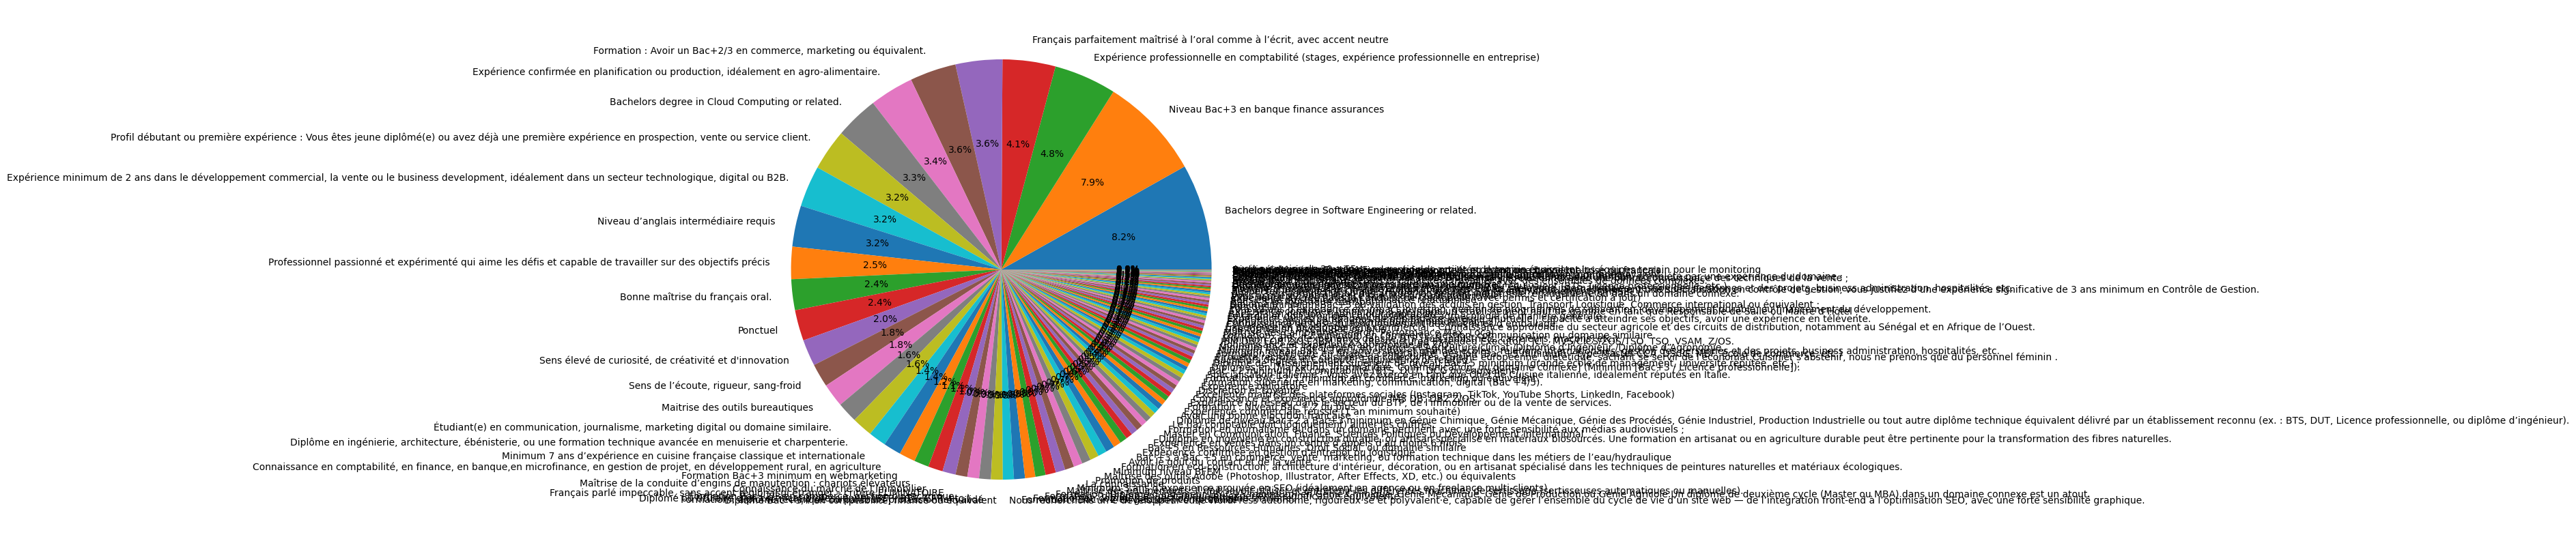

In [72]:
plt.figure(figsize=(15,10))
plt.pie(data_formation["nbre_formation"], labels=data_formation["formation"], autopct="%1.1f%%")
plt.show()

In [73]:
df_formation = df_traite.groupby("formation")\
       .count()\
       .limit(30)\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_formation")\
        .toPandas()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


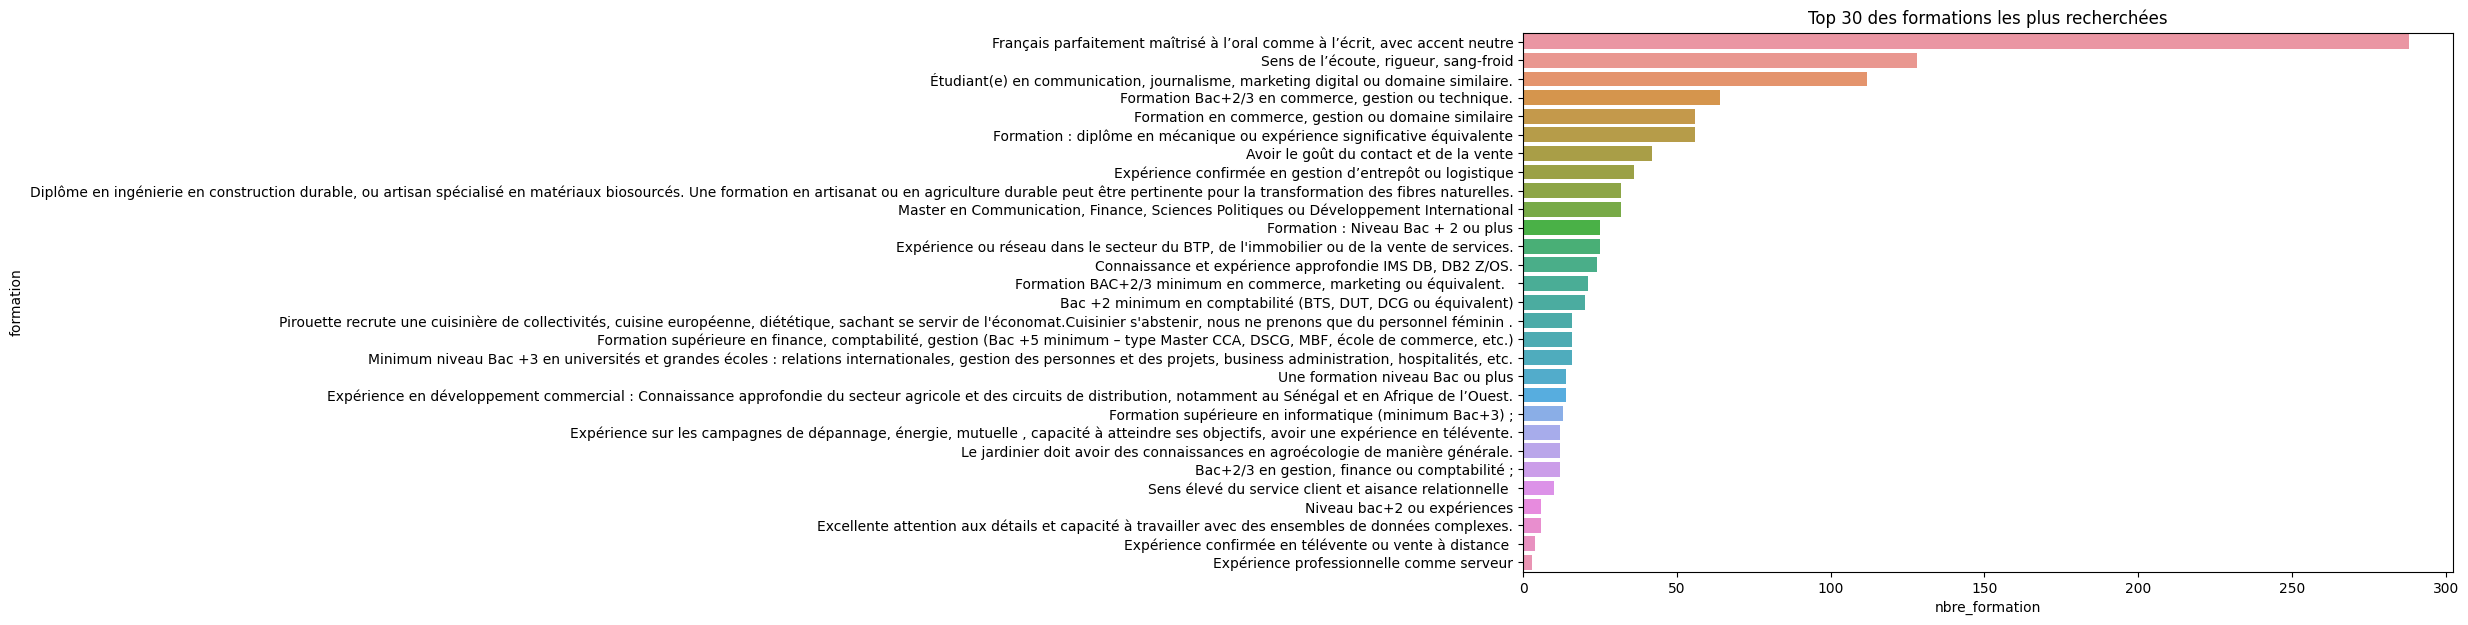

In [74]:
plt.figure(figsize=(12,7))
sns.barplot(data=df_formation, y="formation", x="nbre_formation")
plt.title("Top 30 des formations les plus recherchées")
plt.show()

### Experience

In [75]:
df_traite.groupby("experience")\
       .count()\
       .distinct()\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_experience")\
    .show(10, truncate=False)

+---------------------------------------+---------------+
|experience                             |nbre_experience|
+---------------------------------------+---------------+
|Expérience entre 5 ans et 10 ans       |1573           |
|Expérience entre 2 ans et 5 ans et plus|1368           |
|Etudiant                               |1334           |
|jeune diplômé et plus                  |1311           |
|Expérience > 10 ans                    |648            |
|Débutant < 2 ans et plus               |465            |
|NULL                                   |253            |
|Expérience entre 2 ans et 5 ans        |89             |
|Débutant < 2 ans                       |25             |
|jeune diplômé                          |23             |
+---------------------------------------+---------------+



In [76]:
df_experience = df_traite.groupby("experience")\
       .count()\
       .distinct()\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_experience")\
       .toPandas()

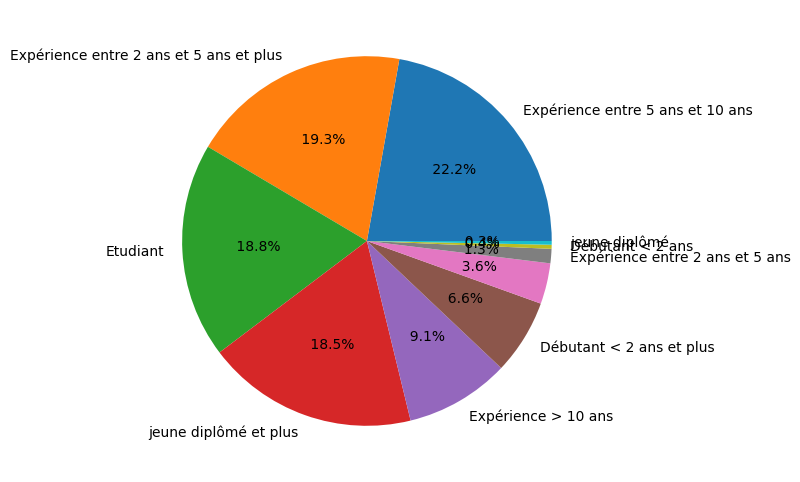

In [77]:
plt.figure(figsize=(6,6))
plt.pie(df_experience["nbre_experience"], labels=df_experience["experience"], autopct="%5.1f%%")
plt.show()

In [78]:
df_traite_clean_exp = df_traite.withColumn(
    "experience_clean",
    when(df_traite.experience == "Expérience entre 2 ans et 5 ans et plus" , "2-5 ans")\
    .when(df_traite.experience == "Expérience entre 2 ans et 5 ans","2-5 ans")\
    .when(df_traite.experience == "Expérience entre 5 ans et 10 ans", "5-10 ans")\
    .when(df_traite.experience == "Débutant < 2 ans", "jeune diplômé Sans expérience")\
    .when(df_traite.experience == "Débutant < 2 ans et plus", "jeune diplômé Sans expérience")\
    .when(df_traite.experience == "jeune diplômé", "jeune diplômé Sans expérience")\
    .otherwise(df_traite.experience))


In [79]:
df_traite_clean_exp.groupby("experience_clean")\
                  .count()\
                  .orderBy(desc("count"))\
                  .withColumnRenamed("count", "nbre_experience")\
                  .show(truncate=False)


+-----------------------------+---------------+
|experience_clean             |nbre_experience|
+-----------------------------+---------------+
|5-10 ans                     |1573           |
|2-5 ans                      |1457           |
|Etudiant                     |1334           |
|jeune diplômé et plus        |1311           |
|Expérience > 10 ans          |648            |
|jeune diplômé Sans expérience|513            |
|NULL                         |253            |
+-----------------------------+---------------+



In [80]:
df_traite_clean_exp_pd = df_traite_clean_exp.groupby("experience_clean").count().orderBy(desc("count"))\
    .withColumnRenamed("count", "nbre_experience").limit(20).toPandas()

In [81]:
data_experience = df_traite.groupby("experience")\
       .count()\
       .limit(20)\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_experience")\
       .toPandas()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


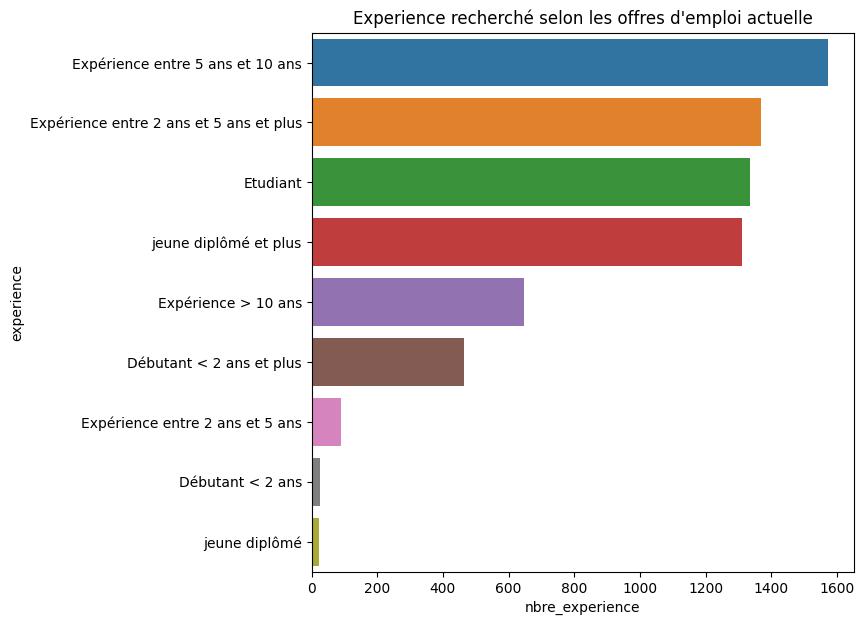

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


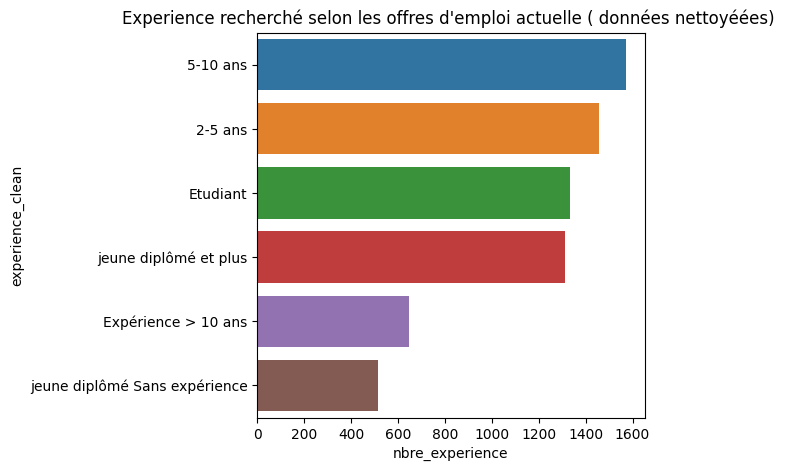

In [82]:
plt.figure(figsize=(7,7))
sns.barplot(data=data_experience, y="experience", x="nbre_experience")
plt.title("Experience recherché selon les offres d'emploi actuelle")
plt.show()

plt.figure(figsize=(5,5))
sns.barplot(data=df_traite_clean_exp_pd , y="experience_clean", x="nbre_experience")
plt.title("Experience recherché selon les offres d'emploi actuelle ( données nettoyéées) ")
plt.show()



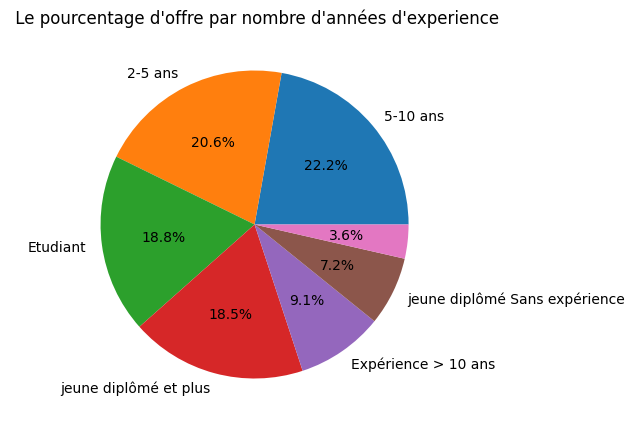

In [83]:
plt.figure(figsize=(5,5))
plt.pie(df_traite_clean_exp_pd["nbre_experience"], labels=df_traite_clean_exp_pd["experience_clean"], autopct="%1.1f%%")
plt.title(" Le pourcentage d'offre par nombre d'années d'experience")
plt.show()

### Colonne contract 

In [84]:
df_traite.groupby("contrat")\
       .count()\
       .distinct()\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_contract")\
    .show(20)

+---------------+-------------+
|        contrat|nbre_contract|
+---------------+-------------+
|            CDD|         1663|
|            CDI|         1595|
|          Stage|         1307|
|      Freelance|          755|
|        Intérim|          497|
|CDD - Freelance|          444|
|           NULL|          253|
|     Alternance|          248|
|  Temps partiel|          191|
|     Statutaire|          100|
|CDI - Freelance|           36|
+---------------+-------------+



In [85]:
df_traite_clean_exp.groupby("contrat")\
                   .count()\
                   .distinct()\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_contract")\
    .show(20)


+---------------+-------------+
|        contrat|nbre_contract|
+---------------+-------------+
|            CDD|         1663|
|            CDI|         1595|
|          Stage|         1307|
|      Freelance|          755|
|        Intérim|          497|
|CDD - Freelance|          444|
|           NULL|          253|
|     Alternance|          248|
|  Temps partiel|          191|
|     Statutaire|          100|
|CDI - Freelance|           36|
+---------------+-------------+



In [86]:
df_traite_clean_contract = df_traite_clean_exp.withColumn(
    "contrat", 
    split(df_traite_clean_exp.contrat,  r"\s*(-)\s*")
)

In [87]:
df_traite_clean_contract.printSchema()

root
 |-- entreprise: string (nullable = true)
 |-- poste: string (nullable = true)
 |-- lien: string (nullable = true)
 |-- competence: string (nullable = true)
 |-- formation: string (nullable = true)
 |-- niveau_etude: string (nullable = true)
 |-- contrat: array (nullable = true)
 |    |-- element: string (containsNull = false)
 |-- experience: string (nullable = true)
 |-- region: string (nullable = true)
 |-- date_de_pulication: string (nullable = true)
 |-- experience_clean: string (nullable = true)



In [88]:
df_traite_clean_contract = df_traite_clean_contract.select(
     df_traite_clean_contract.entreprise, df_traite_clean_contract.poste, df_traite_clean_contract.lien, df_traite_clean_contract.competence,\
     df_traite_clean_contract.formation, df_traite_clean_contract.niveau_etude,\
     explode_outer(df_traite_clean_contract.contrat).alias("contract"),\
     df_traite_clean_contract.experience_clean.alias("experience"),\
     df_traite_clean_contract.region, df_traite_clean_contract.date_de_pulication.alias("date_de_publication")
)


In [89]:
df_traite_clean_contract.withColumn(
    "contract",
        when(col("contract").isNull(), None)
    .otherwise(col("contract"))
)

DataFrame[entreprise: string, poste: string, lien: string, competence: string, formation: string, niveau_etude: string, contract: string, experience: string, region: string, date_de_publication: string]

In [90]:
df_contract = df_traite_clean_contract.groupby("contract")\
       .count()\
       .distinct()\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_contract")\
        .show()

+-------------+-------------+
|     contract|nbre_contract|
+-------------+-------------+
|          CDD|         2107|
|          CDI|         1631|
|        Stage|         1307|
|    Freelance|         1235|
|      Intérim|          497|
|         NULL|          253|
|   Alternance|          248|
|Temps partiel|          191|
|   Statutaire|          100|
+-------------+-------------+



In [91]:
df_contract_pd = df_traite_clean_contract.groupby("contract")\
       .count()\
       .distinct()\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_contract")\
        .toPandas()

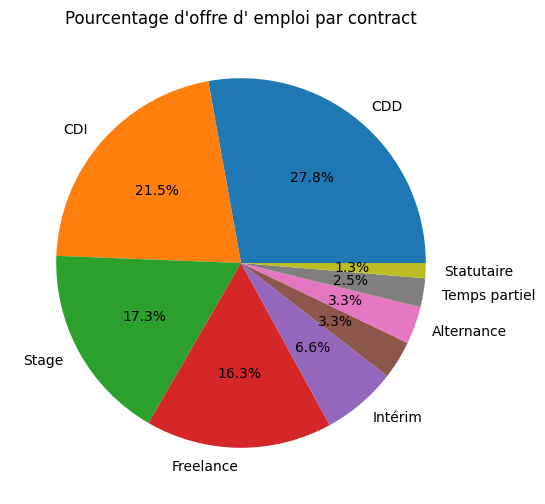

In [92]:
plt.figure(figsize=(6,6))
plt.pie(df_contract_pd["nbre_contract"], labels=df_contract_pd["contract"], autopct="%1.1f%%")
plt.title("Pourcentage d'offre d' emploi par contract" )
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


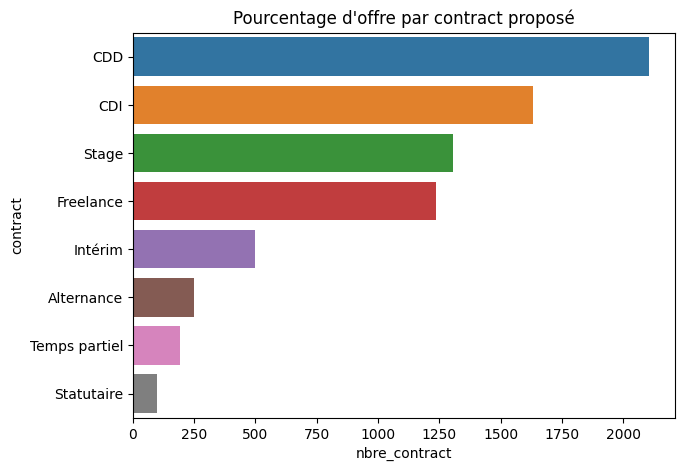

In [93]:
plt.figure(figsize=(7,5))
sns.barplot(data=df_contract_pd, y = df_contract_pd['contract'], x = df_contract_pd['nbre_contract'])
plt.title("Pourcentage d'offre par contract proposé")
plt.show()

## Dataset Netoyée prealeblement...

### # Dans cette premiere partie, nous avons nettoyé notre dataset, en supprimant les valeurs non voulues
### A present, vous allons, a l' etat de la gestion des valeurs manquantes...

In [94]:
df_traite_clean_contract.describe()

DataFrame[summary: string, entreprise: string, poste: string, lien: string, competence: string, formation: string, niveau_etude: string, contract: string, experience: string, region: string, date_de_publication: string]

#### Entreprise

In [95]:
print("nombre de champs nuls dans la colonnes entreprise")
df_traite_clean_contract.filter(col("entreprise").isNull()).count()

nombre de champs nuls dans la colonnes entreprise


340

In [96]:
df_traite_clean_contract.filter(col("entreprise").isNull()).show(5,truncate=False)

+----------+-----------------+----------------------------------------------------+----------+---------------------------------------------------------------------------------------------+------------+---------+----------+------+-------------------+
|entreprise|poste            |lien                                                |competence|formation                                                                                    |niveau_etude|contract |experience|region|date_de_publication|
+----------+-----------------+----------------------------------------------------+----------+---------------------------------------------------------------------------------------------+------------+---------+----------+------+-------------------+
|NULL      |Comptable - Dakar|https://www.emploisenegal.com/recherche-jobs-senegal|Banque    |Expérience professionnelle en comptabilité (stages, expérience professionnelle en entreprise)|Bac+3       |CDD      |2-5 ans   |Dakar |10.07.2025         |


#### Poste 

In [97]:
print("nombre de champs nuls dans la colonne poste")
df_traite_clean_contract.filter(col("poste").isNull()).count()

nombre de champs nuls dans la colonne poste


0

#### Expericence

In [98]:
print("nombre de champs nuls dans la colonne experience")
df_traite_clean_contract.filter(col("experience").isNull()).count()

nombre de champs nuls dans la colonne experience


253

In [99]:
df_traite_clean_contract.filter(col("experience").isNull()).show(5,truncate=False)

+--------------+--------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------+----------+---------+------------+--------+----------+--------------+--------------------------+
|entreprise    |poste                                             |lien                                                                                                                                                  |competence|formation|niveau_etude|contract|experience|region        |date_de_publication       |
+--------------+--------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------+----------+---------+------------+--------+----------+--------------+--------------------------+
|ICRC -CICR    |Gestionnaire des données Protection    

In [100]:
colonnes = ["competence", "formation", "niveau_etude", "contract", "experience"]
df_clean_without_miss1 = df_traite_clean_contract.na.drop(subset=colonnes)

In [101]:
df_clean_without_miss1.filter(col("experience").isNull()).count()

0

#### Formation

In [102]:
print("nombre de champs nuls dans la colonne formation")
df_clean_without_miss1.filter(col("formation").isNull()).count()

nombre de champs nuls dans la colonne formation


0

In [103]:
df_clean_without_miss1.filter(col("formation").isNull()).show(5,truncate=False)

+----------+-----+----+----------+---------+------------+--------+----------+------+-------------------+
|entreprise|poste|lien|competence|formation|niveau_etude|contract|experience|region|date_de_publication|
+----------+-----+----+----------+---------+------------+--------+----------+------+-------------------+
+----------+-----+----+----------+---------+------------+--------+----------+------+-------------------+



#### Niveau etude 

In [104]:
print("nombre de champs nuls dans la colonne niveau_etude")
df_clean_without_miss1.filter(col("niveau_etude").isNull()).count()

nombre de champs nuls dans la colonne niveau_etude


0

In [105]:
df_clean_without_miss1.filter(col("niveau_etude").isNull()).show(5,truncate=False)

+----------+-----+----+----------+---------+------------+--------+----------+------+-------------------+
|entreprise|poste|lien|competence|formation|niveau_etude|contract|experience|region|date_de_publication|
+----------+-----+----+----------+---------+------------+--------+----------+------+-------------------+
+----------+-----+----+----------+---------+------------+--------+----------+------+-------------------+



#### Competence

In [106]:
print("nombre de champs nuls dans la colonnes competence")
df_clean_without_miss1.filter(col("competence").isNull()).count()

nombre de champs nuls dans la colonnes competence


0

In [107]:
df_clean_without_miss1.filter(col("competence").isNull()).show(5,truncate=False)

+----------+-----+----+----------+---------+------------+--------+----------+------+-------------------+
|entreprise|poste|lien|competence|formation|niveau_etude|contract|experience|region|date_de_publication|
+----------+-----+----+----------+---------+------------+--------+----------+------+-------------------+
+----------+-----+----+----------+---------+------------+--------+----------+------+-------------------+



In [108]:
df_clean_without_miss1.filter(col("experience").isNull()).count()

0

In [109]:
df_clean_without_miss1.filter(col("entreprise").isNull()).count()

340

# Notre DataSet clean (propre)

In [110]:
df_propre = df_clean_without_miss1

### Revisualisation 

#### Experience 

In [111]:
df_exp_clean_pd = df_propre.groupby("experience").count().orderBy(desc("count"))\
    .withColumnRenamed("count", "nbre_experience").limit(20).toPandas()

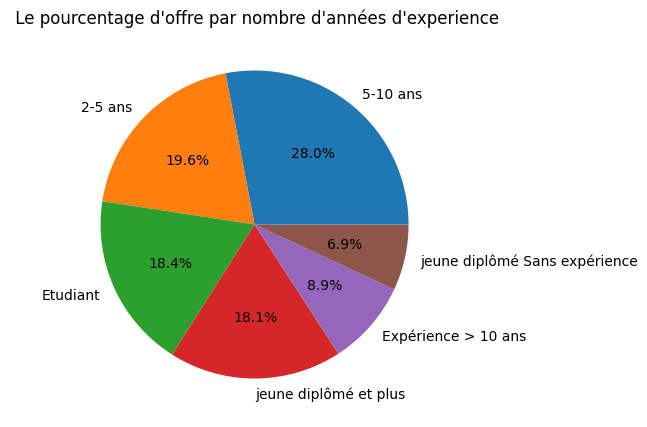

In [112]:
plt.figure(figsize=(5,5))
plt.pie(df_exp_clean_pd["nbre_experience"], labels=df_exp_clean_pd["experience"], autopct="%1.1f%%")
plt.title(" Le pourcentage d'offre par nombre d'années d'experience")
plt.show()

#### Par rapport au niveau d'etude

In [113]:
df_clean_etude = df_propre.groupby("niveau_etude")\
       .count()\
       .distinct()\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_niveau_etude")\
       .toPandas()

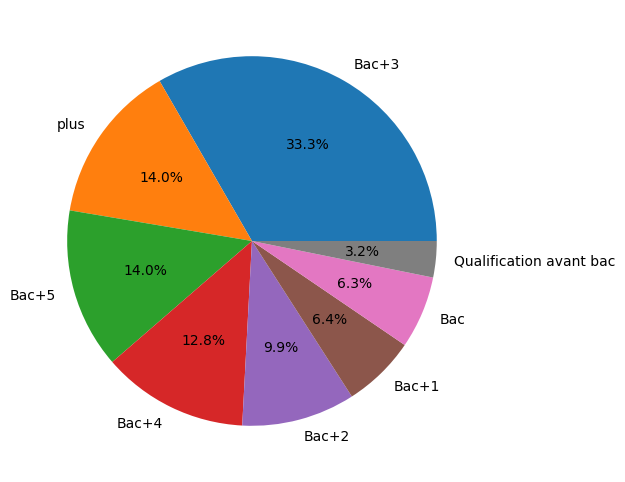

In [114]:
plt.figure(figsize=(6,6))
plt.pie(df_clean_etude["nbre_niveau_etude"], labels=df_clean_etude["niveau_etude"], autopct="%1.1f%%")
plt.show()

In [115]:
df_clean_contract = df_propre.groupby("contract")\
       .count()\
       .distinct()\
       .orderBy(desc("count"))\
       .withColumnRenamed("count", "nbre_contract")\
        .toPandas()

# Analyse croisée ou bivariée 

## Experience * poste 

In [116]:
df_propre.printSchema()

root
 |-- entreprise: string (nullable = true)
 |-- poste: string (nullable = true)
 |-- lien: string (nullable = true)
 |-- competence: string (nullable = true)
 |-- formation: string (nullable = true)
 |-- niveau_etude: string (nullable = true)
 |-- contract: string (nullable = true)
 |-- experience: string (nullable = true)
 |-- region: string (nullable = true)
 |-- date_de_publication: string (nullable = true)



In [117]:
df_exp_poste = df_propre.groupby("experience","poste").count().orderBy(desc("count")).toPandas()

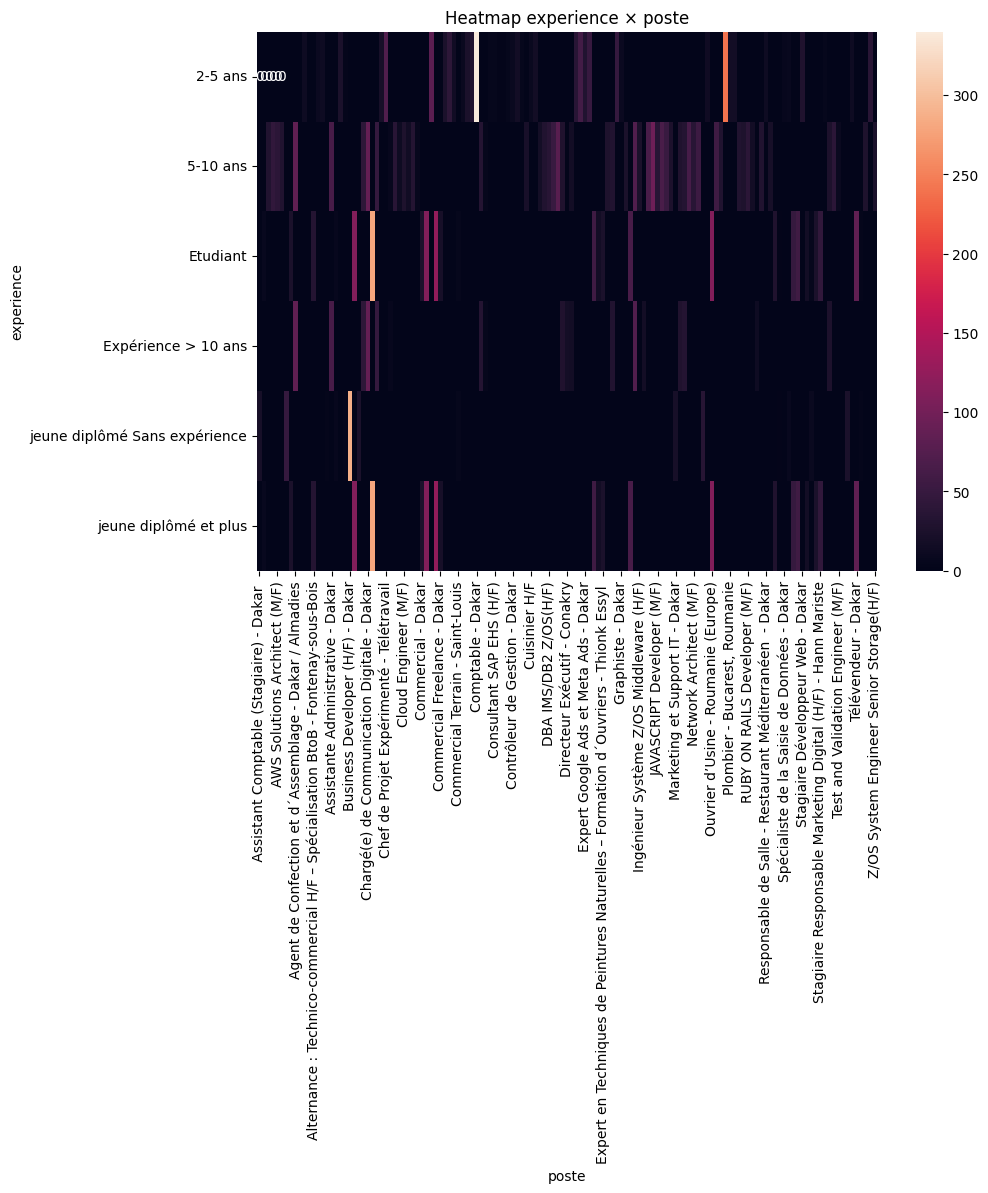

In [118]:
pivot = df_exp_poste.pivot(index="experience", columns="poste", values="count").fillna(0)

plt.figure(figsize=(10,7))
sns.heatmap(pivot, annot=True, fmt="g")
plt.title("Heatmap experience × poste")
plt.show()

## Experience * contract 

In [119]:
df_propre.groupby("experience","contract").count().orderBy(desc("count")).show()

+--------------------+---------+-----+
|          experience| contract|count|
+--------------------+---------+-----+
|            5-10 ans|      CDI|  741|
|            5-10 ans|      CDD|  738|
|            5-10 ans|Freelance|  461|
|            Etudiant|    Stage|  437|
|jeune diplômé et ...|    Stage|  421|
|             2-5 ans|      CDD|  317|
|            Etudiant|      CDD|  306|
|jeune diplômé et ...|      CDD|  306|
|             2-5 ans|Freelance|  286|
| Expérience > 10 ans|      CDI|  284|
|             2-5 ans|      CDI|  283|
| Expérience > 10 ans|      CDD|  272|
|            Etudiant|Freelance|  206|
|jeune diplômé et ...|Freelance|  204|
|             2-5 ans|    Stage|  200|
|jeune diplômé San...|    Stage|  158|
|             2-5 ans|  Intérim|  151|
|jeune diplômé San...|      CDD|  134|
|jeune diplômé et ...|      CDI|  123|
|            Etudiant|      CDI|  123|
+--------------------+---------+-----+
only showing top 20 rows



In [120]:
df_exp_contract = df_propre.groupby("experience","contract").count().orderBy(desc("count")).toPandas()

In [121]:
df_exp_contract.columns

Index(['experience', 'contract', 'count'], dtype='object')

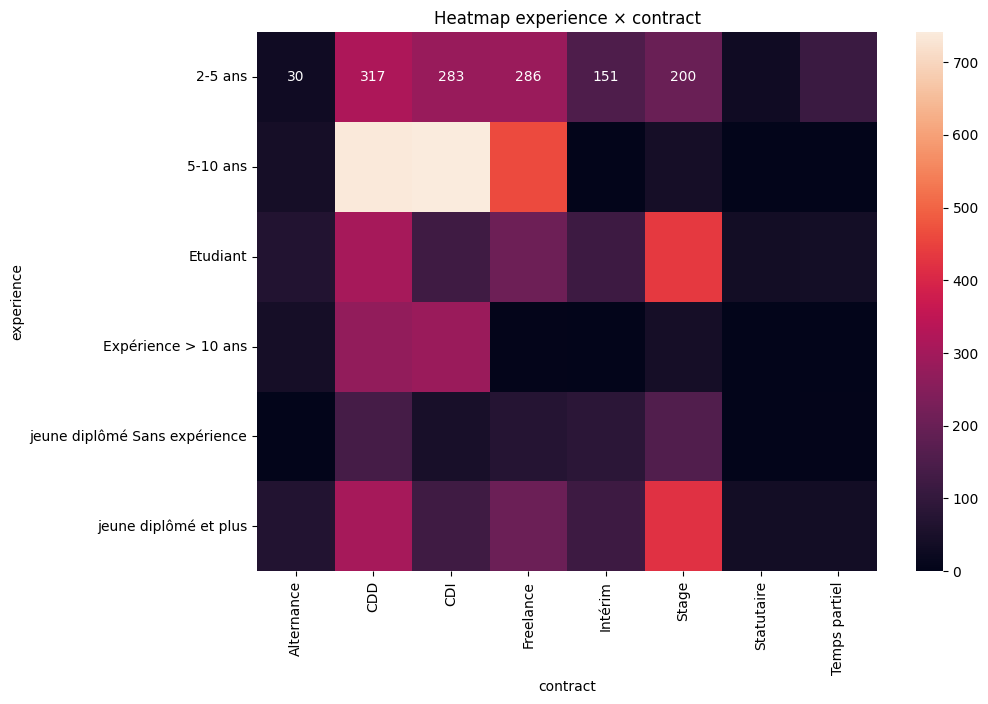

In [122]:
pivot1 = df_exp_contract.pivot(index="experience", columns='contract', values="count").fillna(0)

plt.figure(figsize=(10,7))
sns.heatmap(pivot1, annot=True, fmt="g")
plt.title("Heatmap experience × contract")
plt.show()

# Filter et les requetes SQL 

In [123]:
df_traite.filter(df_traite.competence.isNull())\
         .select(df_traite.poste, df_traite.experience, df_traite.niveau_etude, df_traite.formation).show(truncate=False)

+---------------------------------+--------------------------------+-----------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|poste                            |experience                      |niveau_etude           |formation                                                                                                                                                            |
+---------------------------------+--------------------------------+-----------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Serveur H/F                      |Expérience entre 2 ans et 5 ans |Bac                    |Expérience professionnelle comme serveur                                                                                           

## Analyse avec des requetes SQL

In [124]:
# suppose df_offres est ton DataFrame que tu veux interroger
df_lecture.createOrReplaceTempView("offres_emploi_ml")

# maintenant tu peux exécuter du SQL dans la même session
df_result = spark2.sql("SELECT * FROM offres_emploi_ml WHERE date_de_pulication >= '2025-30-10'")
df_result.show(truncate=False)


+--------------+----------------------------------------+----+------------------------+----------------------------------------------------------------------------------------------------------+------------+-------------+---------------------------------------+------+------------------+
|entreprise    |poste                                   |lien|competence              |formation                                                                                                 |niveau_etude|contrat      |experience                             |region|date_de_pulication|
+--------------+----------------------------------------+----+------------------------+----------------------------------------------------------------------------------------------------------+------------+-------------+---------------------------------------+------+------------------+
|CERAGEM       |Agent Commercial - Dakar                |NULL|Vente                   |La connaissance,                                 

# Enregistrement de dataset propore

In [127]:
df_propre.write.format("jdbc")\
    .option("url", url) \
    .option("dbtable", "dataset_ml_propore") \
    .option("user", user) \
    .option("password", password) \
    .option("driver", driver) \
    .save()

In [128]:
df_propre.count()

7221

### Pour stopper la session 

In [129]:
spark2.stop()

In [130]:
del spark2